#### EDA DECISION TREE

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

### Leer el Dataset 

In [16]:
df= pd.read_csv("../data/raw/diabetes.csv")
df.head

<bound method NDFrame.head of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50 

### Comenzamos con el EDA 

 **Dimensiones y estructura**

In [17]:
print(df.shape)      # Número de filas y columnas
print(df.info())     # Tipos de datos y nulos

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


**Descripción estadística**


In [18]:
print(df.describe().T)  # Estadísticas de variables numéricas

                          count        mean         std     min       25%  \
Pregnancies               768.0    3.845052    3.369578   0.000   1.00000   
Glucose                   768.0  120.894531   31.972618   0.000  99.00000   
BloodPressure             768.0   69.105469   19.355807   0.000  62.00000   
SkinThickness             768.0   20.536458   15.952218   0.000   0.00000   
Insulin                   768.0   79.799479  115.244002   0.000   0.00000   
BMI                       768.0   31.992578    7.884160   0.000  27.30000   
DiabetesPedigreeFunction  768.0    0.471876    0.331329   0.078   0.24375   
Age                       768.0   33.240885   11.760232  21.000  24.00000   
Outcome                   768.0    0.348958    0.476951   0.000   0.00000   

                               50%        75%     max  
Pregnancies                 3.0000    6.00000   17.00  
Glucose                   117.0000  140.25000  199.00  
BloodPressure              72.0000   80.00000  122.00  
SkinT

**Valores nulos y duplicados**


In [19]:
print(df.isnull().sum())      # Nulos por columna
print(df.duplicated().sum())  # Filas duplicadas

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
0


**Variables categóricas**


In [20]:
columnas_object = df.select_dtypes(include='object').columns.tolist()
print(columnas_object)

[]


**Distribución de la variable objetivo**
'Outcome'


In [21]:
#Definir la variable objetivo (target) y las variables predictoras (features)
target = 'Outcome'
X = df.drop(columns=[target])
y = df[target]

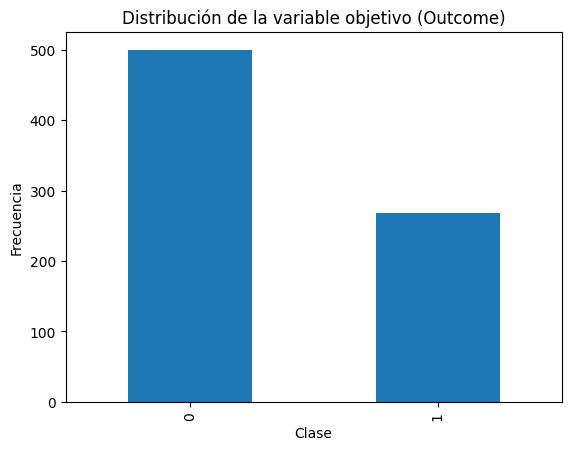

In [22]:
df['Outcome'].value_counts().plot(kind='bar')
plt.title('Distribución de la variable objetivo (Outcome)')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.show()

**Visualización de variables numéricas**


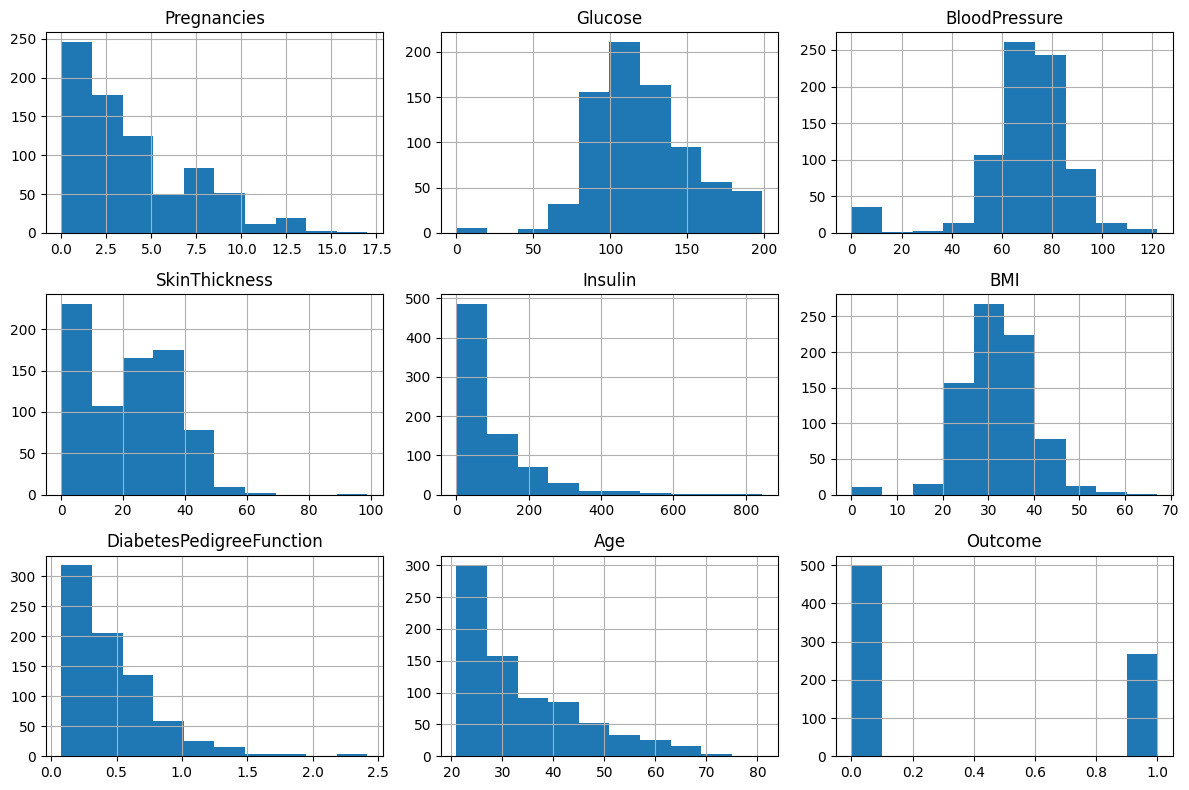

In [23]:
import matplotlib.pyplot as plt
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

**Correlación entre variables**


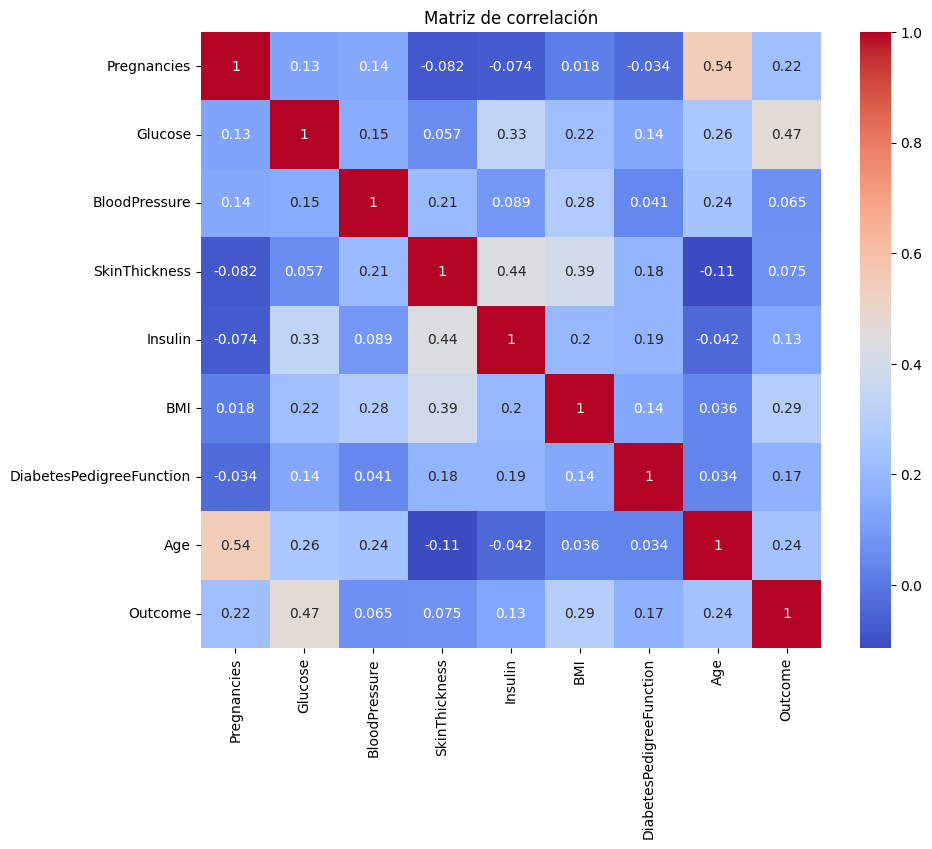

In [24]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

**Detección de outliers**


In [33]:
# Detección de outliers usando el método del rango intercuartílico (IQR)
outliers = {}

for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask = (df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))
    outliers[col] = df[col][outlier_mask]

# Mostrar cuántos outliers hay por variable
for col, vals in outliers.items():
    print(f"{col}: {len(vals)} outliers")

Pregnancies: 4 outliers
Glucose: 5 outliers
BloodPressure: 14 outliers
SkinThickness: 1 outliers
Insulin: 34 outliers
BMI: 19 outliers
DiabetesPedigreeFunction: 29 outliers
Age: 9 outliers
Outcome: 0 outliers


In [26]:
# Reemplazar valores 0 en BloodPressure por la mediana (excepto si 0 es un valor válido)
mediana_bp = df.loc[df['BloodPressure'] != 0, 'BloodPressure'].median()
df['BloodPressure'] = df['BloodPressure'].replace(0, mediana_bp)

In [34]:
# Ver los valores mínimos y máximos
print(df['BloodPressure'].describe())
print(df['Insulin'].describe())

# Ver los valores atípicos concretos
print(df[df['BloodPressure'] < 40])  # Ejemplo de valores sospechosos
print(df[df['Insulin'] > 300])       # Ejemplo de valores muy altos

count    768.000000
mean      72.386719
std       12.096642
min       24.000000
25%       64.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64
count    768.000000
mean      79.799479
std      115.244002
min        0.000000
25%        0.000000
50%       30.500000
75%      127.250000
max      846.000000
Name: Insulin, dtype: float64
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
18             1      103             30             38       83  43.3   
125            1       88             30             42       99  55.0   
597            1       89             24             19       25  27.8   
599            1      109             38             18      120  23.1   

     DiabetesPedigreeFunction  Age  Outcome  
18                      0.183   33        0  
125                     0.496   26        1  
597                     0.559   21        0  
599                     0.407   26        0  
     Pregnanc

In [41]:
# Copia del dataframe para imputación
df_knn = df.copy()

# Reemplazar valores 0 en BloodPressure por NaN (no son fisiológicos)
df_knn['BloodPressure'] = df_knn['BloodPressure'].replace(0, np.nan)

# Marcar outliers en DiabetesPedigreeFunction como NaN usando IQR
col = 'DiabetesPedigreeFunction'
Q1 = df_knn[col].quantile(0.25)
Q3 = df_knn[col].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (df_knn[col] < (Q1 - 1.5 * IQR)) | (df_knn[col] > (Q3 + 1.5 * IQR))
df_knn.loc[outlier_mask, col] = np.nan

# Imputar con KNN solo las columnas numéricas
imputer = KNNImputer(n_neighbors=5)
num_cols = df_knn.select_dtypes(include=np.number).columns
df_knn[num_cols] = imputer.fit_transform(df_knn[num_cols])

# Si quieres, puedes reemplazar el df original:
# df = df_knn

Esto sirve para **imputar valores anómalos y faltantes** en mi DataFrame usando el método KNN (K-Nearest Neighbors Imputer):
>
1. **Copia el DataFrame** para no modificar el original.
2. **Reemplaza los valores 0 en la columna `BloodPressure` por NaN**, ya que 0 no es un valor fisiológico y se considera dato faltante.
3. **Detecta los outliers en la columna `DiabetesPedigreeFunction` usando el método IQR** y los marca como NaN.
4. **Imputa (rellena) los valores NaN de todas las columnas numéricas usando KNNImputer**, que utiliza los valores de los vecinos más cercanos para estimar los valores faltantes o anómalos.

**¿Por qué hago esto?**  
Porque mejora la calidad de mis datos antes de entrenar modelos, evitando que los valores anómalos o faltantes distorsionen los resultados.

Para guardar el nuevo DataFrame imputado (`df_knn`) en un archivo CSV, uso el siguiente código al final de mi notebook:

In [42]:
# Guardar el DataFrame imputado en un nuevo archivo CSV
df_knn.to_csv("../data/processed/diabetes_imputado.csv", index=False)

Esto creará el archivo `diabetes_imputado.csv` en la carpeta processed.  

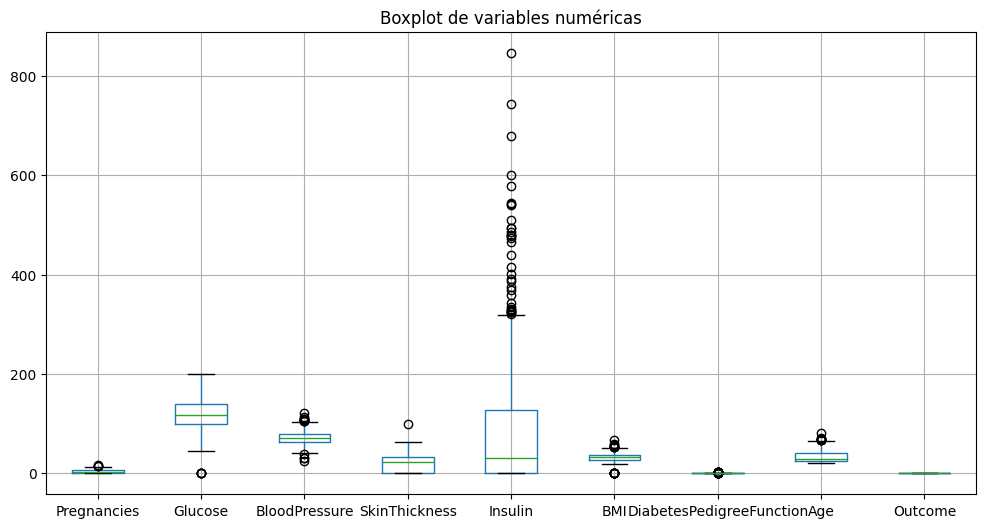

In [43]:
df.boxplot(figsize=(12, 6))
plt.title('Boxplot de variables numéricas')
plt.show()

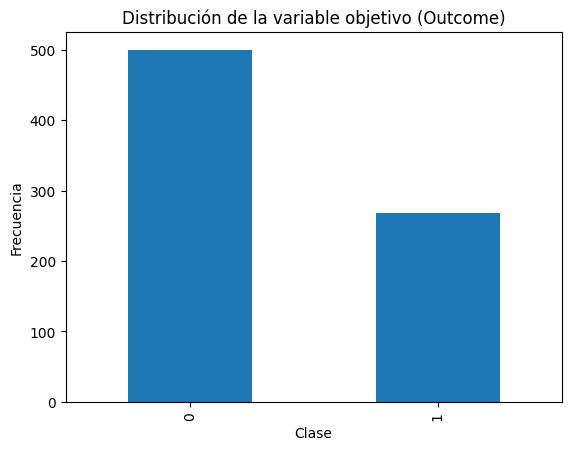

In [44]:
# Gráfico de barras para visualizar la distribución de la variable objetivo (Outcome)
df['Outcome'].value_counts().plot(kind='bar')
plt.title('Distribución de la variable objetivo (Outcome)')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.show()